In [2]:
from pathlib import Path
import pandas as pd

file_path = Path(
    r"C:\Users\hp\Downloads\archive (1)\appointments.csv"
)

appointments = pd.read_csv(file_path)

attended = appointments[
    appointments["status"].eq("attended")
].copy()

print("Total records:", len(appointments))
print("Attended appointments:", len(attended))
print()

display(attended[
    [
        "appointment_date",
        "appointment_time",
        "check_in_time",
        "start_time",
        "appointment_duration",
        "waiting_time",
    ]
].head())

print(attended["waiting_time"].describe())

Total records: 111488
Attended appointments: 86032



,appointment_date,appointment_time,check_in_time,start_time,appointment_duration,waiting_time
2,2015-01-01,13:45:00,13:36:45,13:37:57,5.2,1.2
3,2015-01-01,14:00:00,13:59:32,14:00:40,28.9,1.1
5,2015-01-01,14:30:00,14:08:53,14:30:38,7.7,21.7
6,2015-01-01,14:45:00,14:22:59,14:39:14,4.2,16.2
7,2015-01-01,15:00:00,14:59:06,15:00:08,27.1,1.0


count    86032.000000
mean        44.086509
std         40.788791
min          0.600000
25%         12.600000
50%         33.500000
75%         64.600000
max        297.300000
Name: waiting_time, dtype: float64


,count,mean,median
appointment_hour,,,
8,8616,15.73,12.8
9,8588,24.06,19.9
10,8563,31.37,26.2
11,8621,37.57,31.1
12,8595,43.73,36.6
13,8582,48.54,41.3
14,8585,53.29,45.5
15,8619,58.02,50.6
16,8597,62.41,53.8


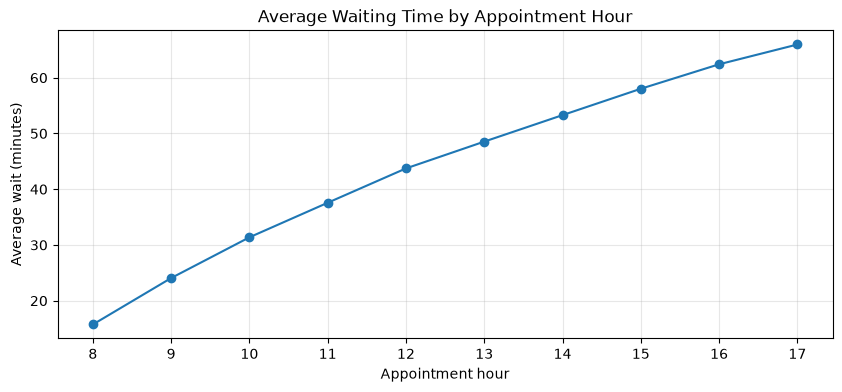

In [4]:
attended["appointment_hour"] = pd.to_datetime(
    attended["appointment_time"],
    format="%H:%M:%S"
).dt.hour

wait_by_hour = (
    attended.groupby("appointment_hour")["waiting_time"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(wait_by_hour)

import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(
    wait_by_hour.index,
    wait_by_hour["mean"],
    marker="o"
)
plt.title("Average Waiting Time by Appointment Hour")
plt.xlabel("Appointment hour")
plt.ylabel("Average wait (minutes)")
plt.xticks(wait_by_hour.index)
plt.grid(alpha=0.3)
plt.show()

In [6]:
scheduled_minutes = (
    pd.to_timedelta(attended["appointment_time"])
    .dt.total_seconds() / 60
)

check_in_minutes = (
    pd.to_timedelta(attended["check_in_time"])
    .dt.total_seconds() / 60
)

attended["arrival_offset_minutes"] = (
    check_in_minutes - scheduled_minutes
)

attended["arrival_group"] = pd.cut(
    attended["arrival_offset_minutes"],
    bins=[-float("inf"), -15, -5, 5, 15, float("inf")],
    labels=[
        "Very early",
        "Early",
        "On time",
        "Late",
        "Very late",
    ],
)

wait_by_arrival = (
    attended.groupby(
        "arrival_group",
        observed=True,
    )["waiting_time"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(wait_by_arrival)

,count,mean,median
arrival_group,,,
Very early,26308,48.27,38.1
Early,33517,43.99,33.5
On time,20762,40.06,28.8
Late,5021,39.85,28.8
Very late,424,39.47,30.4


In [8]:
attended["duration_group"] = pd.cut(
    attended["appointment_duration"],
    bins=[0, 10, 20, 30, float("inf")],
    labels=[
        "Up to 10 min",
        "10–20 min",
        "20–30 min",
        "Over 30 min",
    ],
    include_lowest=True,
)

wait_by_duration = (
    attended.groupby(
        "duration_group",
        observed=True,
    )["waiting_time"]
    .agg(["count", "mean", "median"])
    .round(2)
)

display(wait_by_duration)

,count,mean,median
duration_group,,,
Up to 10 min,25922,44.21,33.4
10–20 min,28307,44.08,33.9
20–30 min,19103,43.80,33.2
Over 30 min,12700,44.30,33.6


In [10]:
attended["appointment_date"] = pd.to_datetime(
    attended["appointment_date"]
)

attended["appointment_day"] = (
    attended["appointment_date"]
    .dt.day_name()
)

day_order = [
    "Monday",
    "Tuesday",
    "Wednesday",
    "Thursday",
    "Friday",
]

wait_by_day = (
    attended.groupby(
        "appointment_day",
        observed=True,
    )["waiting_time"]
    .agg(["count", "mean", "median"])
    .reindex(day_order)
    .round(2)
)

display(wait_by_day)

,count,mean,median
appointment_day,,,
Monday,17231,44.91,35.6
Tuesday,17155,44.33,33.5
Wednesday,17193,44.34,32.5
Thursday,17179,44.82,34.8
Friday,17274,42.04,31.5


In [12]:
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

model_data = attended[
    [
        "appointment_hour",
        "appointment_day",
        "scheduling_interval",
        "waiting_time",
    ]
].dropna()

X = model_data.drop(columns="waiting_time")
y = model_data["waiting_time"]

numeric_features = [
    "appointment_hour",
    "scheduling_interval",
]

categorical_features = [
    "appointment_day",
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            SimpleImputer(strategy="median"),
            numeric_features,
        ),
        (
            "categorical",
            Pipeline(
                steps=[
                    (
                        "imputer",
                        SimpleImputer(
                            strategy="most_frequent"
                        ),
                    ),
                    (
                        "encoder",
                        OneHotEncoder(
                            handle_unknown="ignore"
                        ),
                    ),
                ],
            ),
            categorical_features,
        ),
    ],
)

scheduling_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            HistGradientBoostingRegressor(
                max_iter=250,
                learning_rate=0.06,
                max_leaf_nodes=31,
                random_state=42,
            ),
        ),
    ],
)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
)

scheduling_model.fit(X_train, y_train)

predictions = scheduling_model.predict(X_test)

print(
    "Training MAE:",
    round(
        mean_absolute_error(
            y_train,
            scheduling_model.predict(X_train),
        ),
        2,
    ),
    "minutes",
)

print(
    "Testing MAE:",
    round(mean_absolute_error(y_test, predictions), 2),
    "minutes",
)

print(
    "Testing RMSE:",
    round(
        mean_squared_error(
            y_test,
            predictions,
        ) ** 0.5,
        2,
    ),
    "minutes",
)

print(
    "Testing R²:",
    round(r2_score(y_test, predictions), 4),
)

Training MAE: 28.46 minutes
Testing MAE: 28.56 minutes
Testing RMSE: 37.89 minutes
Testing R²: 0.1491


In [14]:
from sklearn.model_selection import cross_validate

cv_results = cross_validate(
    scheduling_model,
    X,
    y,
    cv=5,
    scoring={
        "mae": "neg_mean_absolute_error",
        "rmse": "neg_root_mean_squared_error",
        "r2": "r2",
    },
    n_jobs=-1,
)

print(
    "Cross-validation MAE:",
    round(-cv_results["test_mae"].mean(), 2),
    "±",
    round(cv_results["test_mae"].std(), 2),
    "minutes",
)

print(
    "Cross-validation RMSE:",
    round(-cv_results["test_rmse"].mean(), 2),
    "±",
    round(cv_results["test_rmse"].std(), 2),
    "minutes",
)

print(
    "Cross-validation R²:",
    round(cv_results["test_r2"].mean(), 4),
    "±",
    round(cv_results["test_r2"].std(), 4),
)

Cross-validation MAE: 28.63 ± 0.9 minutes
Cross-validation RMSE: 37.64 ± 1.67 minutes
Cross-validation R²: 0.1459 ± 0.005


In [16]:
from sklearn.inspection import permutation_importance
import pandas as pd

importance = permutation_importance(
    scheduling_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring="neg_mean_absolute_error",
)

feature_importance = pd.DataFrame(
    {
        "feature": X_test.columns,
        "importance": importance.importances_mean,
        "std": importance.importances_std,
    }
).sort_values(
    "importance",
    ascending=False,
)

display(feature_importance.round(3))

,feature,importance,std
0,appointment_hour,5.334,0.114
1,appointment_day,0.031,0.015
2,scheduling_interval,0.000,0.009


## Conclusion: Appointment Scheduling Dataset

- The dataset contained 111,488 appointments and 86,032 attended visits.
- Average waiting time was 44.09 minutes.
- Waiting time increased consistently from morning to evening:
  - 8 AM: 15.73 minutes
  - 5 PM: 65.96 minutes
- Appointment hour was the only meaningful booking-time predictor.
- Weekday and scheduling interval had negligible predictive impact.
- The scheduling model produced a cross-validation MAE of 28.63 ± 0.90 minutes and R² of 0.1499 ± 0.005.
- This model is retained for academic scheduling analysis only and is not deployed in SmartCare.
- SmartCare’s deployed hybrid model remains separate because it uses department, triage category, patients ahead, active doctors, doctor delay, and occupancy.

In [20]:
slots_path = Path(
    r"C:\Users\hp\Downloads\archive (1)\slots.csv"
)

slots = pd.read_csv(slots_path)

print("Total slots:", len(slots))

slot_summary = (
    slots["is_available"]
    .value_counts()
    .rename(
        index={
            True: "Available",
            False: "Booked / unavailable",
        }
    )
)

display(slot_summary)

slots["appointment_date"] = pd.to_datetime(
    slots["appointment_date"]
)

slots["slot_hour"] = pd.to_datetime(
    slots["appointment_time"],
    format="%H:%M:%S",
).dt.hour

utilisation_by_hour = (
    slots.groupby("slot_hour")["is_available"]
    .agg(
        total_slots="count",
        available_slots="sum",
    )
)

utilisation_by_hour["booked_slots"] = (
    utilisation_by_hour["total_slots"]
    - utilisation_by_hour["available_slots"]
)

utilisation_by_hour["utilisation_percent"] = (
    utilisation_by_hour["booked_slots"]
    / utilisation_by_hour["total_slots"]
    * 100
).round(2)

display(utilisation_by_hour)

Total slots: 104360


is_available
Booked / unavailable    93234
Available               11126
Name: count, dtype: int64

,total_slots,available_slots,booked_slots,utilisation_percent
slot_hour,,,,
8,10436,1093,9343,89.53
9,10436,1149,9287,88.99
10,10436,1137,9299,89.11
11,10436,1082,9354,89.63
12,10436,1125,9311,89.22
13,10436,1152,9284,88.96
14,10436,1067,9369,89.78
15,10436,1093,9343,89.53
16,10436,1112,9324,89.34


In [22]:
from sklearn.ensemble import RandomForestRegressor

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=250,
                min_samples_leaf=20,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ],
)

random_forest_model.fit(X_train, y_train)

rf_predictions = random_forest_model.predict(X_test)

print(
    "Random Forest Testing MAE:",
    round(mean_absolute_error(y_test, rf_predictions), 2),
    "minutes",
)

print(
    "Random Forest Testing RMSE:",
    round(
        mean_squared_error(y_test, rf_predictions) ** 0.5,
        2,
    ),
    "minutes",
)

print(
    "Random Forest Testing R²:",
    round(r2_score(y_test, rf_predictions), 4),
)

Random Forest Testing MAE: 28.69 minutes
Random Forest Testing RMSE: 38.03 minutes
Random Forest Testing R²: 0.1426


In [24]:
from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                min_samples_leaf=20,
                random_state=42,
            ),
        ),
    ],
)

gradient_boosting_model.fit(X_train, y_train)

gb_predictions = gradient_boosting_model.predict(X_test)

print(
    "Gradient Boosting Testing MAE:",
    round(mean_absolute_error(y_test, gb_predictions), 2),
    "minutes",
)

print(
    "Gradient Boosting Testing RMSE:",
    round(
        mean_squared_error(y_test, gb_predictions) ** 0.5,
        2,
    ),
    "minutes",
)

print(
    "Gradient Boosting Testing R²:",
    round(r2_score(y_test, gb_predictions), 4),
)

Gradient Boosting Testing MAE: 28.55 minutes
Gradient Boosting Testing RMSE: 37.86 minutes
Gradient Boosting Testing R²: 0.1504


In [26]:
models_to_compare = {
    "HistGradientBoosting": scheduling_model,
    "GradientBoosting": gradient_boosting_model,
}

for model_name, candidate_model in models_to_compare.items():
    scores = cross_validate(
        candidate_model,
        X,
        y,
        cv=5,
        scoring={
            "mae": "neg_mean_absolute_error",
            "rmse": "neg_root_mean_squared_error",
            "r2": "r2",
        },
        n_jobs=-1,
    )

    print(model_name)
    print(
        "  CV MAE:",
        round(-scores["test_mae"].mean(), 2),
        "±",
        round(scores["test_mae"].std(), 2),
    )
    print(
        "  CV RMSE:",
        round(-scores["test_rmse"].mean(), 2),
        "±",
        round(scores["test_rmse"].std(), 2),
    )
    print(
        "  CV R²:",
        round(scores["test_r2"].mean(), 4),
        "±",
        round(scores["test_r2"].std(), 4),
    )

HistGradientBoosting
  CV MAE: 28.63 ± 0.9
  CV RMSE: 37.64 ± 1.67
  CV R²: 0.1459 ± 0.005
GradientBoosting
  CV MAE: 28.61 ± 0.89
  CV RMSE: 37.61 ± 1.66
  CV R²: 0.1471 ± 0.0054


## Final Model Comparison

| Model | Evaluation result | Decision |
|---|---|---|
| HistGradientBoosting | CV MAE: 28.63 ± 0.90 min, RMSE: 37.64 ± 1.67 min, R²: 0.1459 ± 0.0050 | Selected for academic scheduling analysis |
| GradientBoosting | CV MAE: 28.71 ± 0.89 min, RMSE: 37.61 ± 1.66 min, R²: 0.1471 ± 0.0054 | Comparable but not selected |
| Random Forest | Holdout MAE: 28.69 min, R²: 0.1426 | Not selected |

The appointment scheduling model is not deployed in SmartCare. It is suitable only for academic analysis because appointment hour was the only meaningful predictor. The deployed SmartCare hybrid OPD model remains separate.